In [1]:
#Checking: is Takahashi prediction usually lower or higher under varying cone angles?

import pandas as pd
import numpy as np
import datetime as dt
import glob

from heatmap_modules import compute_hists2d
from heatmap_plotting_modules import CA_binned_plot

##load Cluster CSVs

cl_file_list = []

path = "/Users/roseatkinson/Documents/Cluster_Int_CSVs/**"

for path in glob.glob(path, recursive=True):
    if '.csv' in path:
        cl_file_list.append(path)
    
cl_dfs = []

for file in cl_file_list:
    df = pd.read_csv(file,encoding='utf-8')
    df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
    df.set_index('datetime', inplace = True)
    cl_dfs.append(df)

cl_power_all = pd.concat(cl_dfs)

print("dfs loaded in")

#Filtering: remove times when OMNI source sc was too far from X-line, & current sheets, & filter down to -5<Zgipm<5 "plane"
cl_filtered = cl_power_all.loc[(cl_power_all['OMNI Dist from X line (mean)'] < 70) & (cl_power_all['Max IMF Deviation'] < 60)]
cl_filtered_lowZ = cl_filtered.loc[(cl_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_filtered['GIPM Z (OMNI mean)'] > -5)]

#add a row normalised by OMNI mag field average... I should be doing this at the source really.
# cl_filtered_lowZ['Normalised Transverse Frequency'] = (cl_filtered_lowZ['Peak Transverse Frequency']/cl_filtered_lowZ['IMF B (mean)'])
# cl_filtered_lowZ['Normalised Compressive Frequency'] = (cl_filtered_lowZ['Peak Compressive Frequency']/cl_filtered_lowZ['IMF B (mean)'])

cl_filtered_lowZ['Takahashi Transverse Error/Measurement Resolution'] = cl_filtered_lowZ['Takahashi Transverse Difference']/0.004166666666666667
cl_filtered_lowZ['Takahashi Compressive Error/Measurement Resolution'] = cl_filtered_lowZ['Takahashi Compressive Difference']/0.004166666666666667
cl_filtered_lowZ['Heilig Transverse Error/Measurement Resolution'] = cl_filtered_lowZ['Heilig Transverse Difference']/0.004166666666666667
cl_filtered_lowZ['Heilig Compressive Error/Measurement Resolution'] = cl_filtered_lowZ['Heilig Compressive Difference']/0.004166666666666667

cl_filtered_lowZ['Takahashi Transverse Error'] = cl_filtered_lowZ['Takahashi Transverse Difference']/cl_filtered_lowZ['Peak Transverse Frequency']
cl_filtered_lowZ['Takahashi Compressive Error'] = cl_filtered_lowZ['Takahashi Compressive Difference']/cl_filtered_lowZ['Peak Compressive Frequency']
cl_filtered_lowZ['Heilig Transverse Error'] = cl_filtered_lowZ['Heilig Transverse Difference']/cl_filtered_lowZ['Peak Transverse Frequency']
cl_filtered_lowZ['Heilig Compressive Error'] = cl_filtered_lowZ['Heilig Compressive Difference']/cl_filtered_lowZ['Peak Compressive Frequency']

#Split only by cone angle, not M_A

CA_bounds_narrow = {"rad": [0,30], "lowspir": [30,45], "highspir": [45,60],"lowperp": [60,75], "highperp": [75,90]}

#filter by cone angle and mach no:

def ca_filter(ca_lims):
    ca_filt = cl_filtered_lowZ.loc[(cl_filtered_lowZ['cone angle (mean)'] >= ca_lims[0]) & (cl_filtered_lowZ['cone angle (mean)'] < ca_lims[1])]
    return(ca_filt)

CA_filtered_frames = {}

for ca_key, ca_bounds in CA_bounds_narrow.items():
    CA_filtered_frames[ca_key] = ca_filter(ca_bounds)

print("CA-only filtered")

dfs loaded in
CA-only filtered


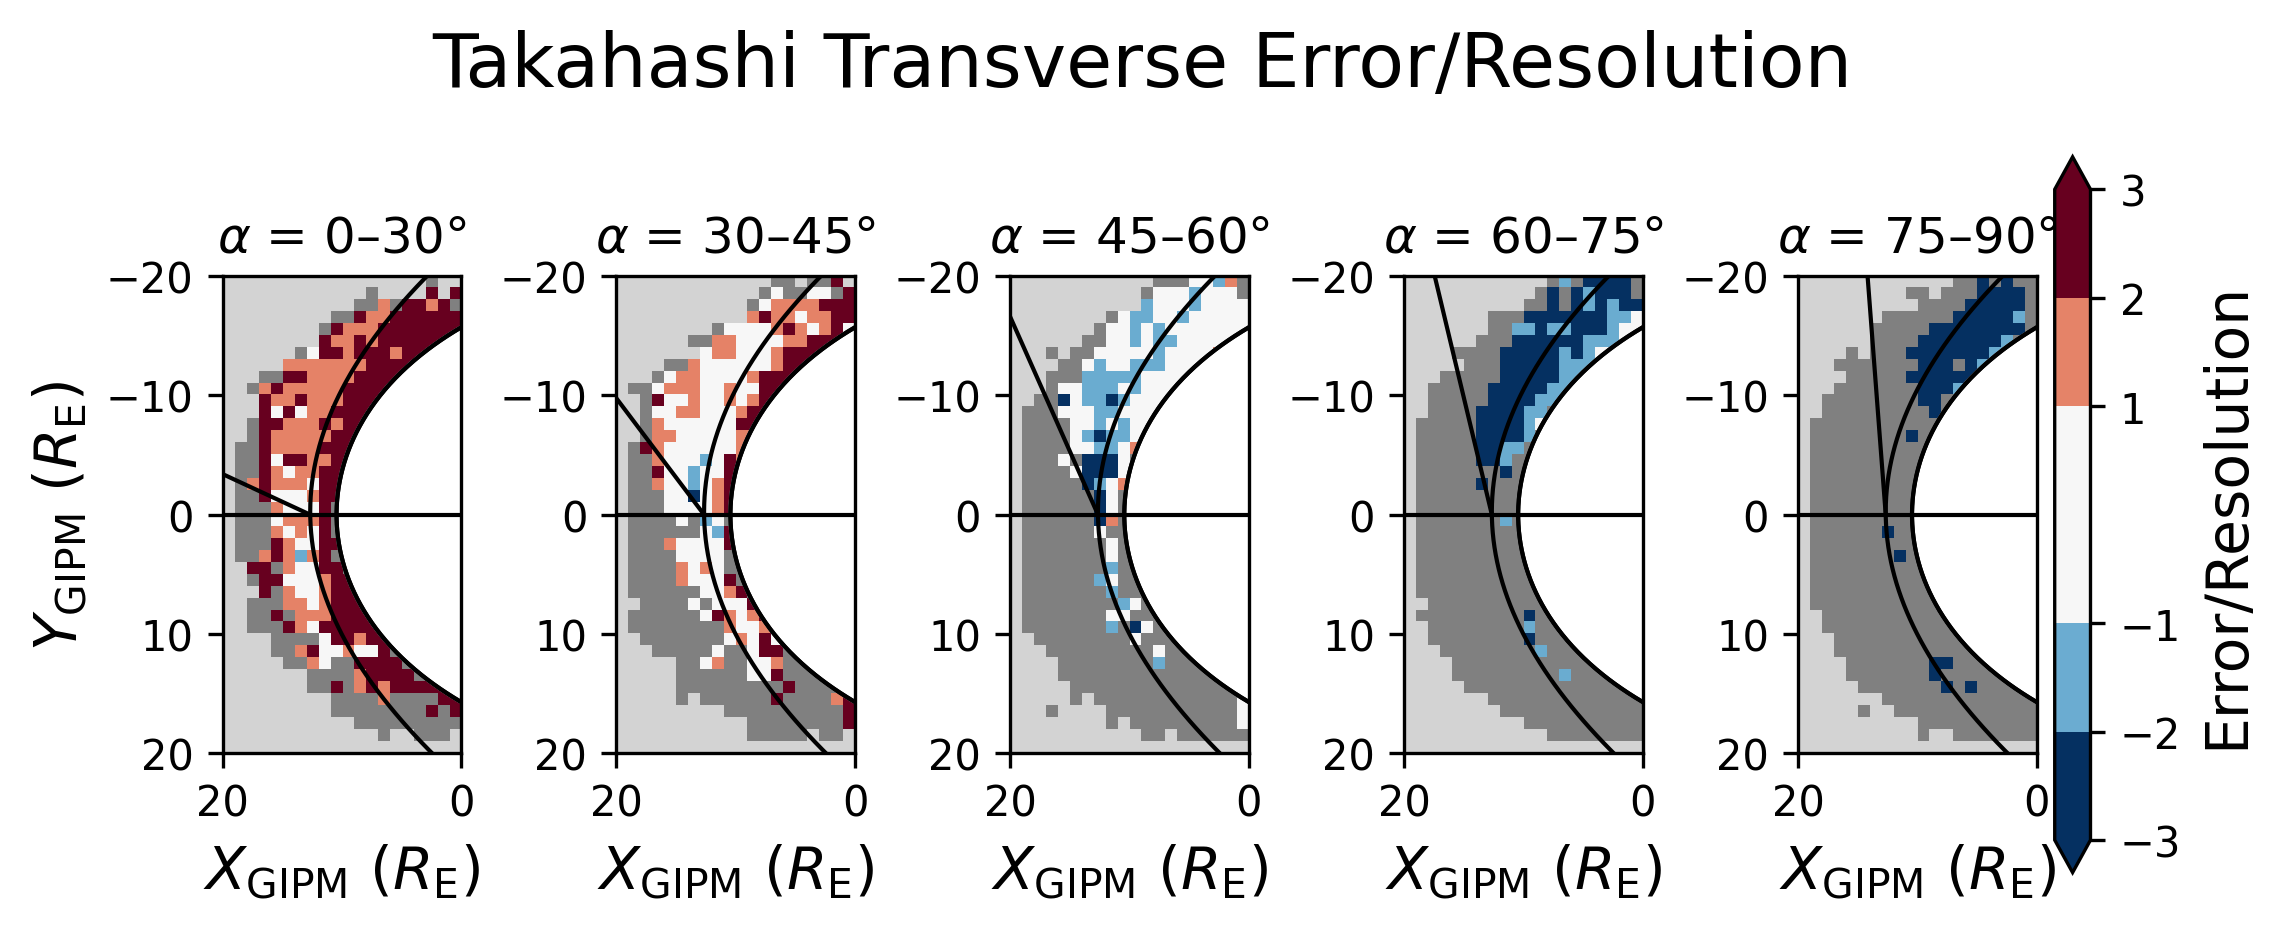

In [2]:
#df, metric, *keys, **choices
#'Transverse Power', 'Compressive Power', 'Compressibility', 'Compressive Frequency', 'Transverse Frequency', 'Ellipticity'
#'Takahashi Transverse Error/Resolution', 'Takahashi Compressive Error/Resolution', 'Heilig Transverse Error/Resolution'
#'Takahashi Transverse Difference', 'Takahashi Compressive Difference', 'Heilig Transverse Difference'

heatmaps_dict_no_filt = {}

for group_name, df in CA_filtered_frames.items():
    heatmaps_dict_no_filt[group_name]= compute_hists2d(df, 'mean', 'Takahashi Transverse Error/Resolution', 'Takahashi Compressive Error/Resolution', obs_min=50)

#hm = {'rad':{'Transverse Power': hist, 'Compressive Power': hist}, etc.}

filtered_heatmap_c_dict = {}
#set all non-NaN values to 1.5 for mapping purposes
for group_name, result_dict in heatmaps_dict_no_filt.items():
    filtered_heatmap_c_dict[group_name]={}
    for quantity_name, result_hist in heatmaps_dict_no_filt[group_name].items():
        result_hist[np.isnan(result_hist) == False] = 1.5
        filtered_heatmap_c_dict[group_name][quantity_name] = result_hist

# for heatmap in heatmaps_dict_no_filt:
#     heatmap[np.isnan(heatmap) == False] = 1.5
#     filtered_heatmap_c.append(heatmap)

heatmaps_dict = {}

for group_name, df in CA_filtered_frames.items():
    #filtering
    df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
    #produce dicts
    heatmaps_dict[group_name]= compute_hists2d(df_ULF, 'mean', 'Takahashi Transverse Error/Resolution', 'Takahashi Compressive Error/Resolution', obs_min=50)

CA_binned_plot('Takahashi Transverse Error/Resolution', heatmaps_dict, background=filtered_heatmap_c_dict)

In [3]:
#now for filtered SW, find std dev in each bin:

std_dict = {}

for group_name, df in CA_filtered_frames.items():
    #print(group_name)
    df_ULF = df.loc[(df['ULF Band Normalised Transverse Power'] > 0.05)]
    std_dict[group_name] = compute_hists2d(df_ULF, 'count', 'Transverse Frequency', obs_min=50)
    hist_std,x_edge, y_edge, _ = compute_hists2d(df_ULF, 'std', 'Transverse Frequency', obs_min=50)
    hist_new = np.where(np.isnan(hist_count), np.nan, hist_std)

#hm = {'rad':{'count': hist, 'Peak Transverse Frequency': hist}, etc.}

error_over_std = {}

for group_name, property_dict in 
    error_over_std_hm = error_hm/std_hm

NameError: name 'stats' is not defined